In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words=open('names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
# itos

In [ ]:
# block_size=3
# X,Y=[],[]
# for w in words:
#     # print(w)
#     context=[0]*block_size
#     for ch in w+'.':
#         ix=stoi[ch]
#         X.append(context)
#         Y.append(ix)
#         # print(''.join(itos[i] for i in context), '--->',itos[ix])
#         context=context[1:]+[ix]
# X=torch.tensor(X)
# Y=torch.tensor(Y)    

In [353]:
block_size=3
def build_dataset(words):
    block_size=3
    X,Y=[],[]
    for w in words:
        # print(w)
        context=[0]*block_size
        for ch in w+'.':
            ix=stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->',itos[ix])
            context=context[1:]+[ix]
    X=torch.tensor(X)
    Y=torch.tensor(Y)    
    print(X.shape,Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1=int(.8*len(words))
n2=int(.9*len(words))

Xtr,Ytr=build_dataset(words[:n1])
Xdev,Ydev=build_dataset(words[n1:n2])
Xte,Yte=build_dataset(words[n2:])

torch.Size([182691, 3]) torch.Size([182691])
torch.Size([22793, 3]) torch.Size([22793])
torch.Size([22662, 3]) torch.Size([22662])


3

In [101]:
C=torch.randn((27,2))
F.one_hot(torch.tensor(5),num_classes=27).float() @ C

tensor([-1.0024, -1.5851])

In [103]:
emb=C[Xtr]


In [105]:
# [emb[:, 0, :],emb[:, 1, :],emb[:, 2, :]]

In [107]:
W1=torch.randn((6,100))
b1=torch.randn(100)

In [109]:
# [emb[:, 0, :],emb[:, 1, :],emb[:, 2, :]]
# torch.cat([emb[:, 0, :],emb[:, 1, :],emb[:, 2, :]],1)
# torch.cat(torch.unbind(emb,1),1)
# (torch.unbind(emb,1),1) is eqaul to [emb[:, 0, :],emb[:, 1, :],emb[:, 2, :]
# it just used here so that even when we have to increase the box -
# sincee it doesnt matter since unbind will automatically do it

In [111]:
h=emb.view(-1,6)@ W1+b1
h.shape


torch.Size([182441, 100])

In [113]:
W2=torch.randn(100,27)
b2=torch.randn(27)

In [115]:
logits=h@W2 +b2


In [374]:
 # Better way----just better style
g=torch.Generator().manual_seed(2147483647)
C=torch.randn((27,10),generator=g)
w1=torch.randn((30,200),generator=g)
b1=torch.randn(200,generator=g)
w2=torch.randn((200,27),generator=g)
b2=torch.randn(27,generator=g)
parameters=[C,w1,b1,w2,b2]


In [376]:
sum(p.nelement() for p in parameters)

11897

In [379]:
# counts=logits.exp()
# prob=counts/counts.sum(1,keepdim=True)
# loss=-prob[torch.arange(32),Y].log().mean()
# loss=F.cross_entropy(logits,Y)

In [381]:
for p in parameters:
    p.requires_grad=True

In [383]:
lre=torch.linspace(-3,0,1000)
lrs=10**lre

In [385]:
lri=[]
lossi=[] 
stepi=[]

In [416]:
for i in range(150000):
    # minibatch construct
    ix=torch.randint(0,Xtr.shape[0],(32,))
    
    # forward pass
    emb=C[Xtr[ix]]
    h=torch.tanh(emb.view(-1,30)@ w1+b1)
    logits=h@w2 +b2
    loss=F.cross_entropy(logits,Ytr[ix])
    # backward pass
    for p in parameters:
        p.grad=None
    loss.backward()
    # update
    # lr=lrs[i]
    lr=.1 if i<100000 else .01
    for p in parameters:
        p.data-=lr*p.grad

    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())
        
print(loss.item())

2.299084186553955


 plt.plot(stepi,lossi)

In [421]:
emb=C[Xdev]
h=torch.tanh(emb.view(-1,30)@ w1+b1)
logits=h@w2 +b2
loss=F.cross_entropy(logits,Ydev)
loss

tensor(2.1274, grad_fn=<NllLossBackward0>)

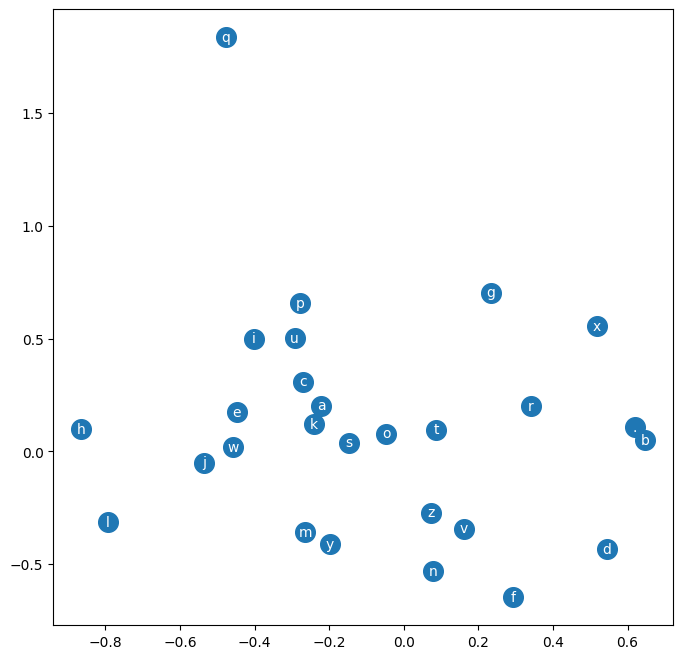

In [423]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data,C[:,1].data,s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(),C[i,1].item(),itos[i],ha="center",va="center",color='white')

In [427]:
g= torch.Generator().manual_seed(2147483647)
for i in range(20):
    out=[]
    context=[0]*block_size
    while True:
         emb=C[torch.tensor([context])]
         h=torch.tanh(emb.view(1,-1)@w1+b1)
         logits=h@w2+b2
         probs=F.softmax(logits,dim=1)
         ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
         context=context[1:]+[ix]
         out.append(ix)
         if ix == 0:
             break
    print(''.join(itos[i] for i in out))

naiyah.
jer.
aais.
aj.
johannah.
mari.
jamaraanly.
jailam.
emberlyn.
adalisa.
ele.
wisalistid.
merajherlee.
stine.
zaelis.
ana.
kassa.
nyn.
rayslin.
yagehra.
